# K-means Clustering and PCA Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Task 1: 2D Dataset Clustering

In [2]:
data_2d = pd.read_csv('data/data_2d.csv')
data_2d.head()

,0.000000000000000000e+00,-7.687164597386728637e-01,4.608603078297135447e-01
0,0.0,2.687848,2.366961
1,0.0,-0.201379,0.470430
2,0.0,0.608496,1.225400
3,0.0,-0.082282,1.137218
4,0.0,2.083069,2.694482


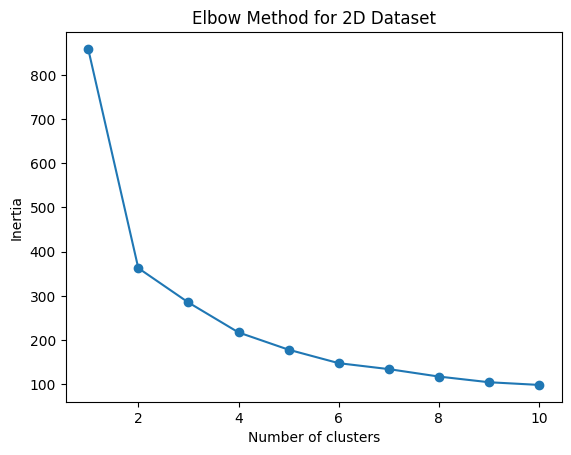

In [3]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_2d)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for 2D Dataset')
plt.show()

In [4]:
kmeans_2d = KMeans(n_clusters=3, random_state=42)
labels_2d = kmeans_2d.fit_predict(data_2d)

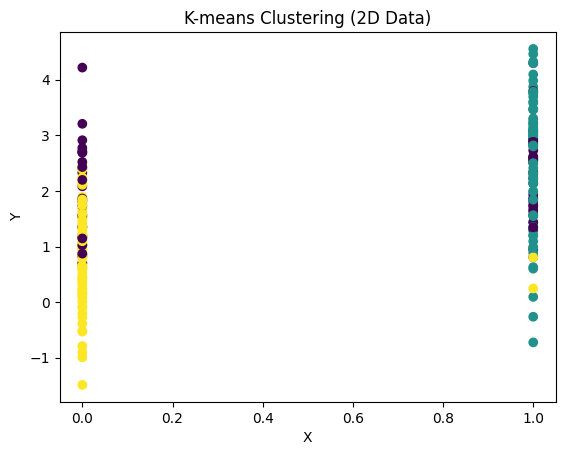

In [5]:
plt.scatter(data_2d.iloc[:, 0], data_2d.iloc[:, 1], c=labels_2d)
plt.title('K-means Clustering (2D Data)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

## Task 2: MNIST Clustering with PCA

In [6]:
mnist = pd.read_csv('data/mnist.csv')
X = mnist.iloc[:, 1:]
y = mnist.iloc[:, 0]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

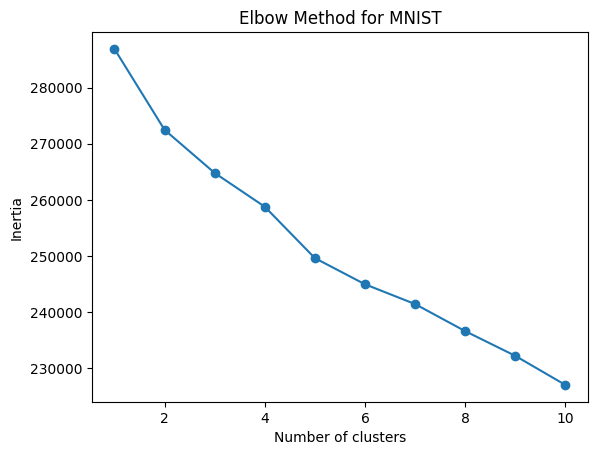

In [8]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for MNIST')
plt.show()

In [9]:
kmeans_mnist = KMeans(n_clusters=10, random_state=42)
labels_mnist = kmeans_mnist.fit_predict(X_scaled)

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

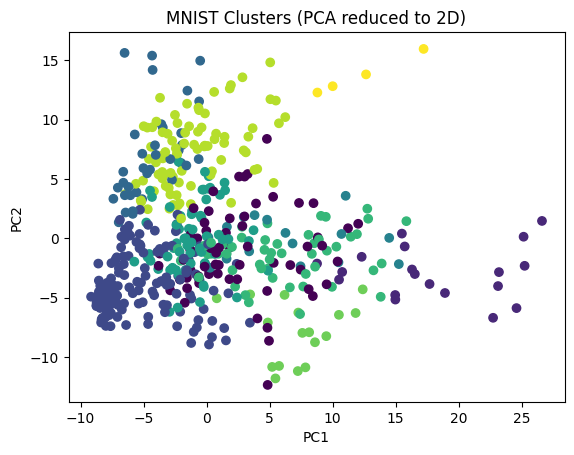

In [11]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_mnist)
plt.title('MNIST Clusters (PCA reduced to 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()